# 🎯 머신러닝 알고리즘의 숨겨진 수학 수수께끼 풀기

이 강의노트는 **42H: 머신러닝** 1장~4장에서 다룬 알고리즘들이 "대체 왜 이런 공식을 쓸까?"에 대한 궁금증을 쉽고 직관적으로 풀어보는 공간이다.

- **RMSE**: 오차를 그냥 더하지 않고, 왜 굳이 복잡하게 제곱해서 평균을 내는가? (1장, 2장)
- **시그모이드**: 선형 회귀로 나온 점수를 어떻게 0~100%짜리 '확률'로 바꿀 수 있는가? (4장 로지스틱 회귀)
- **소프트맥스**: 결과값이 여러 개일 때, 어떻게 합쳐서 자연스럽게 1(100%)이 되게 만드는가? (4장 소프트맥스 회귀)

> 🤯 복잡하고 딱딱한 수식 증명보다는, "아하! 그래서 그랬구나!" 하고 무릎을 탁 칠 수 있는 쉬운 비유들을 담았다. 편안한 마음으로 읽어보자!

---
## 1. RMSE와 정규분포

### 1.1 오차란 무엇인가? 📏

2장에서 우리는 캘리포니아 주택 가격을 예측하는 회귀 모델을 훈련시켰다.  
가령 모델이 어떤 집의 가격을 **3억 원**으로 예측했는데 실제 가격이 **3억 2천만 원**이라면, 여기서 발생한 오차는 **2천만 원**이다.

우리는 전체 데이터에 대해 이 오차를 하나하나 계산할 수 있다. 이때 중요한 것은 **'이 오차들이 전체적으로 어떤 모양(분포)을 띠고 있는가'**이다.

### 1.2 오차는 왜 하필 예쁜 '종 모양(정규분포)'을 띨까? 🔔

현실에서 모델이 100% 정답을 맞히지 못하고 '오차'를 내는 이유는 무수히 많다. 집값을 예로 들어보자.
- 집 근처에 갑자기 신상 맛집과 예쁜 공원이 생겨서 (집값을 5천만 원 올린다 🔼)
- 집주인이 급하게 이사를 가야 해서 (집값을 1천만 원 내린다 🔽)
- 그날따라 날씨가 좋아서 채광이 좋아 보여서 (집값을 5백만 원 올린다 🔼)
- 그 외 우리가 모르는 수십, 수백 가지의 자잘한 변수들...

이 작은 변수들은 서로 눈치 보지 않고(독립적으로) 제멋대로 집값을 올리거나 내린다.
그리고 이 수많은 요인들이 **다 함께 뒤섞여 나타난 최종 결과물이 바로 하나의 큰 '오차'**가 된다.

통계학에서는 이를 설명하는 **중심극한정리(Central Limit Theorem)**라는 마법 같은 법칙이 있다. 
> "아무리 제멋대로 분포된 작은 원인들이라도, 그것들이 수없이 많이 합쳐지면 결국 그 합은 예쁜 종 모양(정규분포)을 띠게 된다!" 

따라서 **"수백 가지 변수를 다 알 수는 없어도, 이것들이 합쳐진 최종 오차는 무조건 정규분포 모양일 것이다"**라고 안심하고 가정할 수 있다.

정규분포 곡선을 띠는 오차는 다음과 같은 특징을 가진다.
- 오차가 **0 근처(정답)**에 가장 많이 몰려 있다 → 모델이 대부분은 얼추 비슷하게 맞춘다 😉
- 오차가 **클수록 빈도가 드물어진다** → 터무니없이 크게 틀리는 경우는 어쩌다 한 번뿐이다 📉
- **플러스 오차와 마이너스 오차가 대칭적**이다 → 위아래로 틀리는 비율이 엇비슷하다 ⚖️

In [20]:
errors.shape

(10000,)

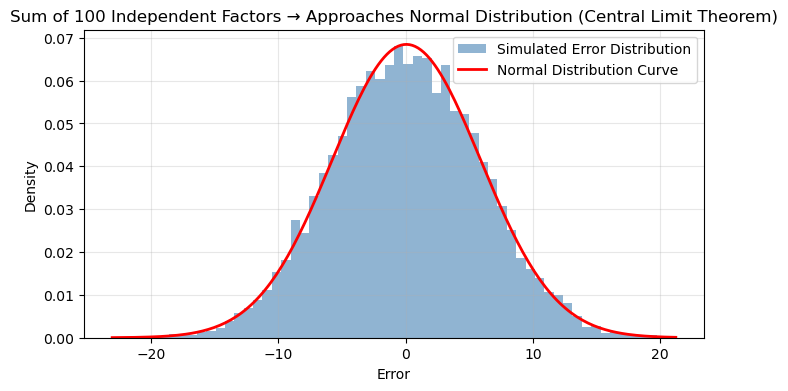

Each factor follows a uniform distribution, but the sum approximates a normal distribution.


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 독립적인 작은 요인 100개를 합쳐서 오차를 시뮬레이션
np.random.seed(42)
n_samples = 10000
n_factors = 100

# 각 요인은 균등분포를 따름 (정규분포가 아님)
factors = np.random.uniform(-1, 1, size=(n_samples, n_factors))

# 오차 = 요인들의 합
errors = factors.sum(axis=1)

x = np.linspace(errors.min(), errors.max(), 200)
pdf = stats.norm.pdf(x, errors.mean(), errors.std())

plt.figure(figsize=(8, 4))
plt.hist(errors, bins=60, density=True, alpha=0.6, color='steelblue', label='Simulated Error Distribution')
plt.plot(x, pdf, 'r-', linewidth=2, label='Normal Distribution Curve')
plt.title('Sum of 100 Independent Factors → Approaches Normal Distribution (Central Limit Theorem)')
plt.xlabel('Error')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print('Each factor follows a uniform distribution, but the sum approximates a normal distribution.')

### 1.3 정규분포의 핵심 성질 📉

정규분포의 확률밀도함수(확률을 나타내는 공식)는 다음과 같다.

$$f(e) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{e^2}{2\sigma^2}\right)$$

여기서 우리가 주목해야 할 핵심은 뒷부분이다.

$$\exp\left(-\frac{e^2}{2\sigma^2}\right)$$

오차 $e$가 커질수록 이 값은 단순히 비례해서 줄어드는 게 아니라 **폭발적으로 작아진다**.
왜냐하면 오차 $e$가 고스란히 **제곱($e^2$)**이 되어 지수(exp) 자리에 올라가 있기 때문이다. 

In [2]:
import numpy as np

# 오차 크기에 따른 확률밀도 변화
errors = np.array([0, 1, 2, 3, 4, 5])
sigma = 1.0
prob_density = np.exp(-errors**2 / (2 * sigma**2))

print('Probability Density by Error Size (Normalized)')
print('-' * 40)
for e, p in zip(errors, prob_density):
    bar = '█' * int(p * 30)
    print(f'Error = {e:2d}  →  {p:.6f}  {bar}')

print()
print('Even a small increase in error causes the probability density to drop drastically.')
print('This is why RMSE is highly sensitive to large errors.')

Probability Density by Error Size (Normalized)
----------------------------------------
Error =  0  →  1.000000  ██████████████████████████████
Error =  1  →  0.606531  ██████████████████
Error =  2  →  0.135335  ████
Error =  3  →  0.011109  
Error =  4  →  0.000335  
Error =  5  →  0.000004  

Even a small increase in error causes the probability density to drop drastically.
This is why RMSE is highly sensitive to large errors.


### 1.4 정규분포 가정에서 RMSE가 탄생하는 마법 🪄

오차가 정규분포를 따른다고 가정하면, 모델 훈련의 목표를 다음과 같이 세울 수 있다.

> **"현재 우리가 가진 데이터가 우연히 나타날 확률(가능성)을 가장 100%에 가깝게 높이는 파라미터를 찾아라!"**  
> (이를 통계학에서는 **최대우도추정, MLE**라고 부른다.)

각 샘플의 예측은 서로 독립적이므로, 전체 데이터 집합이 그대로 나올 확률은 1번 샘플 확률 $\times$ 2번 샘플 확률 $\times \cdots$ 식으로 기차처럼 전부 곱해서 구한다.

$$P \propto \exp(-e_1^2) \times \exp(-e_2^2) \times \cdots \times \exp(-e_n^2) = \exp\left(-(e_1^2 + e_2^2 + \cdots + e_n^2)\right)$$

수식을 보라! 지수(exp)끼리 곱했더니 윗부분의 수식들이 몽땅 **덧셈**으로 묶였다.
결국 이 전체 수학적 확률($P$)을 **최대화**하려면, 괄호 안의 마이너스 붙은 값 부분을 오히려 **최소화**해야만 한다.

$$e_1^2 + e_2^2 + \cdots + e_n^2 \text{ 를 최소화하라!}$$

이것이 바로 머신러닝에서 입이 닳도록 외치던 **"오차 제곱의 합(MSE)을 최소화"**하라는 말과 수학적으로 완전히 똑같은 뜻이 된다. 여기에 숫자 크기 단위를 맞추기 위해 겉에 루트(Root)를 씌우면 드디어 수식의 끝판왕 **RMSE**가 탄생한다.

> **결론**: RMSE는 누군가 대충 그럴싸해서 만든 공식이 아니다. **"우리의 오차는 정규분포를 따른다"는 믿음(가정) 하에 수학적으로 한 치의 오차 없이 필연적으로 도출**될 수밖에 없는 눈부신 결과물이다! ✨

### 1.5 만약 정규분포 가정이 깨진다면? (RMSE vs MAE) 🥊

2장에서 세 모델의 성능을 비교할 때 RMSE를 잣대로 썼던 것을 기억해 보자.

| 모델 | 훈련셋 RMSE | 교차 검증 평균 RMSE |
|------|------------|-------------------|
| 선형 회귀 | 약 68,688 | 약 7만 |
| 결정트리 | 0 | 약 6만7천 |
| 랜덤 포레스트 | 약 17,474 | 약 4만7천 |

그런데 만약 데이터에 엉뚱한 이상치(터무니없이 비싼 집, 오류 데이터 등)가 구석구석 너무 많아서 오차가 예쁜 종 모양(정규분포)을 띠지 않는다면 어떻게 해야 할까?
이럴 때는 RMSE 대신 **MAE(평균 절대 오차)**를 쓰는 것이 훨씬 현명하고 안전하다.  

왜일까? RMSE는 식에 오차의 **'제곱'**이 고스란히 들어있기 때문에, 뚱딴지같은 큰 오차 하나가 발생하면 전체 지표가 곱절 그 이상으로 무지막지하게 뻥튀기되어 모델의 성능을 크게 왜곡해 버리기 때문이다.

In [3]:
import numpy as np

# 이상치가 있을 때 RMSE vs MAE 비교
errors_normal  = np.array([1, -2, 3, -1, 2])    # 정상적인 오차
errors_outlier = np.array([1, -2, 3, -1, 100])  # 이상치 포함

def rmse(errors):
    return np.sqrt(np.mean(errors**2))

def mae(errors):
    return np.mean(np.abs(errors))

print('Without Outliers')
print(f'  RMSE: {rmse(errors_normal):.2f}')
print(f'  MAE:  {mae(errors_normal):.2f}')
print()
print('With Outliers (one error = 100)')
print(f'  RMSE: {rmse(errors_outlier):.2f}  ← Very sensitive to outliers')
print(f'  MAE:  {mae(errors_outlier):.2f}   ← Relatively less sensitive to outliers')

Without Outliers
  RMSE: 1.95
  MAE:  1.80

With Outliers (one error = 100)
  RMSE: 44.75  ← Very sensitive to outliers
  MAE:  21.40   ← Relatively less sensitive to outliers


---
## 2. 시그모이드와 베르누이 분포

### 2.1 로지스틱 회귀의 출력값은 왜 확률인가? 🎲

4장에서 배우는 로지스틱 회귀는 이름에만 달랑 "회귀"가 붙어 있을 뿐, 사실 뼛속까지 **분류 모델**이다.  
이 모델의 핵심은 그냥 크고 작은 점수를 찍어내는 것이 아니라, 그 출력값을 **0에서 1 사이의 똑부러진 '확률'**로 해석한다는 점이다.

1장에서 다루었던 스팸 메일 분류를 떠올려 보자.

> "무료 당첨! 지금 클릭하세요" → 스팸일 확률 **0.97 (97%)**  
> "내일 점심 메뉴 뭐 먹을까요?" → 스팸일 확률 **0.02 (2%)**

마치 일기예보 방송에서 "내일 비 올 확률 90%"라고 말하는 것처럼, 모델이 자신이 선택을 내린 것에 대해 **얼마나 확신하고 있는지**를 우리에게 친절한 확률 숫자로 솔직하게 알려주는 셈이다.

### 2.2 동전 던지기 (베르누이 분포) 🪙

자, 이제 스팸이냐 정상 메일이냐처럼 **결과가 딱 두 가지로만 나뉘는 상황**을 떠올려보자. 통계학에서는 이 상황을 꽤나 근사하게 **베르누이 분포**라고 부른다.  
어렵게 생각할 것 없이 그냥 **'동전 던지기'**의 다른 말이다.

- 동전 던지기: 앞면(1) 또는 뒷면(0), 그리고 앞면이 나올 확률은 $p$
- 스팸 분류: 스팸(1) 또는 정상(0), 그리고 스팸일 확률은 $p$

유일한 차이점이 있다면 현실에 굴러다니는 진짜 동전은 $p = 0.5$ (50%)로 고정되어 있지만,  
우리 스팸 모델에서는 **이메일(데이터)을 열어볼 때마다 그 우수성에 따라 스팸일 확률 $p$가 카멜레온처럼 매번 계속해서 바뀐다**는 것이다.

로지스틱 회귀의 진짜 속마음은 바로 이것이다.
> **"이 이메일이 가진 특징(단어, 길이 등 특성)들을 아주 꼼꼼히 따져본 뒤, 이 특정 이메일에 꼭 맞는 맞춤형 확률 $p$를 구해주겠다!"**

### 2.3 시그모이드 함수는 대체 어디서 튀어나왔나? 📉

우리가 배운 1차원 선형 회귀가 계산해낸 날것의 내부 점수(출력값)는 $-\infty$에서 $+\infty$까지 끝없이 뻗어 나가는 무제한의 숫자들이다.  
하지만 '확률'이라는 녀석은 세상이 두 쪽 나도 무조건 **0(0%)과 1(100%) 사이**에 갇혀 있어야 한다. 이 괴리를 어떻게 해결할까?

이때 특급 구원투수로 **로짓(Logit) 변환**이라는 게 등장한다. 이것은 0~1 사이의 좁은 우물 안 확률 $p$를 제약 없는 넓디넓은 실수 세상으로 마법처럼 변환해 주는 공식이다.

$$\text{로짓}(p) = \log\left(\frac{p}{1-p}\right)$$

| $p$ (확률) | 로짓 값 (무한 실수 점수) |
|----------|-------|
| 0.01 | -4.6 |
| 0.5  | 0.0  |
| 0.99 | +4.6 |

로지스틱 회귀는 선형 회귀가 뱉어낸 점수를 바로 저 '로짓 값'과 같다고 두고 당당하게 식을 세워버린다.  
그리고 그 식을 거꾸로 뒤집어 **$p = \dots$** 형태로 예쁘게 풀고 나면! 짜잔, 우리가 아는 **시그모이드 함수**가 마법처럼 도출된다.

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

> **결론**: 시그모이드는 그저 그래프 S자 모양이 예뻐서 누군가 억지로 갖다 붙인 게 아니다.  
> **'결과가 두 개인 베르누이 분포' + '로짓 변환'**이라는 수학적 여정을 성실히 따라가다 보면 **도착할 수밖에 없는 유일한 수학적 종착지**인 셈이다! 💡

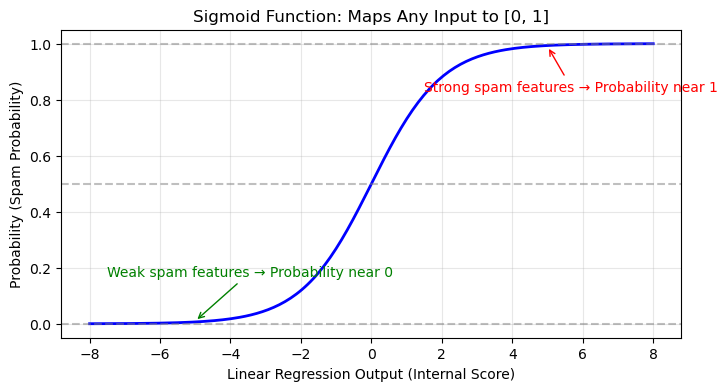

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-8, 8, 200)
y = sigmoid(x)

plt.figure(figsize=(8, 4))
plt.plot(x, y, 'b-', linewidth=2)
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=0.0, color='gray', linestyle='--', alpha=0.5)
plt.title('Sigmoid Function: Maps Any Input to [0, 1]')
plt.xlabel('Linear Regression Output (Internal Score)')
plt.ylabel('Probability (Spam Probability)')
plt.annotate('Strong spam features → Probability near 1', xy=(5, 0.99), xytext=(1.5, 0.83),
             arrowprops=dict(arrowstyle='->', color='red'), color='red')
plt.annotate('Weak spam features → Probability near 0', xy=(-5, 0.01), xytext=(-7.5, 0.17),
             arrowprops=dict(arrowstyle='->', color='green'), color='green')
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
# 시그모이드는 모델 내부 점수를 확률로 번역하는 장치
scores = [-5, -2, 0, 2, 5]
print('Internal Score → Probability (Sigmoid)')
print('-' * 40)
for s in scores:
    p = sigmoid(s)
    print(f'Score {s:+3d}  →  Prob {p:.4f}  ({"Spam" if p > 0.5 else "Normal"})')

Internal Score → Probability (Sigmoid)
----------------------------------------
Score  -5  →  Prob 0.0067  (Normal)
Score  -2  →  Prob 0.1192  (Normal)
Score  +0  →  Prob 0.5000  (Normal)
Score  +2  →  Prob 0.8808  (Spam)
Score  +5  →  Prob 0.9933  (Spam)


---
## 3. 소프트맥스와 카테고리 분포

### 3.1 주사위 굴리기 (다중 분류 문제) 🎲

3장에서 풀었던 MNIST 손글씨 이미지는 스팸/정상처럼 동전 던지기식 문제가 아니다. 0부터 9까지 **10개의 옵션 중 진짜 정답 하나**를 콕 집어 골라야 한다. 

이렇게 여러 개의 결과 중 무조건 하나가 튀어나오는 상황을 통계학의 세계에서는 **카테고리 분포**라고 부른다.  
쉽게 말해 모양이 각기 다른 **'주사위 던지기'**다. 던져서 나올 수 있는 결과의 가짓수는 여러 가지지만, 이 모든 확률을 전부 하나로 모아 합치면 무조건 100%(1)가 되어야 한다는 빡빡하고도 절대적인 규칙이 있다.

베르누이(동전)와 카테고리(주사위) 분포를 한눈에 비교해 보자.

| | 베르누이 분포 | 카테고리 분포 |
|---|---|---|
| **친숙한 비유** | 동전 던지기 (앞면 또는 뒷면) | 주사위 던지기 (1에서 6, 혹은 그 이상 등) |
| **결과 수** | 딱 2가지 | 여러 가지 |
| **머신러닝 예시** | 스팸 메일 분류하기 | 사진 보고 0~9 손글씨 숫자 맞히기 |

### 3.2 이번엔 소프트맥스 함수다! 📊

동전 던지기(베르누이 분포)에서 **로짓 변환**이 뚝딱뚝딱 계산되어 '시그모이드'를 낳았듯,  
주사위 던지기(카테고리 분포)의 세상에서는 아주 깔끔한 **로그(Log) 변환**이라는 과정을 거쳐 **'소프트맥스(Softmax)'**라는 함수가 탄생한다.

각 버튼(클래스 확률)이 눌릴 확률 $p_k$에 단순히 로그를 씌우고 그 값이 모델 점수 $z_k$에 비례한다고 둔 뒤, "모든 클래스 확률의 합은 무조건 1이다"라는 엄격한 룰을 적용해 수식을 정리해 보라. 그러면 너무나 자연스럽게 아래의 소프트맥스 공식이 완성된다.

$$p_k = \frac{\exp(z_k)}{\sum_{j} \exp(z_j)}$$
*(해석: 전체 점수의 $\exp$를 다 더한 것 중, 내 점수의 $\exp$가 차지하는 비율이 곧 나의 당첨 확률이다!)*

| | 베르누이 분포 (로지스틱 회귀) | 카테고리 분포 (소프트맥스 회귀) |
|---|---|---|
| **옵션 개수** | 딱 2개 | 여러 개 (N개) |
| **수학적 마법** | 로짓 변환 | 로그 변환 |
| **최종 창조된 함수** | **시그모이드 (Sigmoid)** | **소프트맥스 (Softmax)** |
| **지켜야 할 규칙** | 나의 확률은 $0 \leq p \leq 1$ | 모두의 확률을 다 합치면 짜잔, 딱 **1**! |

> 이진 분류가 다중 분류의 정말 스페셜한 버전(클래스가 딱 2개인 순간)이듯,  
> 사실 **로지스틱 회귀(시그모이드)도 소프트맥스 공식에 '클래스를 2개만 집어넣었을 때' 나오는 특수한 버전의 방정식**일 뿐이다. 두 함수는 피눈물이 얽힌 진짜 형제 사이나 다름없다! 👬

MNIST Digit Classification Result (Image of digit 5)
---------------------------------------------
Digit 0: score= -2.1  prob=0.0016  
Digit 1: score= -3.5  prob=0.0004  
Digit 2: score= -1.2  prob=0.0040  
Digit 3: score= -2.8  prob=0.0008  
Digit 4: score= -1.5  prob=0.0030  
Digit 5: score=  4.3  prob=0.9828  ███████████████████████████████████████ ← predicted
Digit 6: score= -2.0  prob=0.0018  
Digit 7: score= -1.8  prob=0.0022  
Digit 8: score= -2.3  prob=0.0013  
Digit 9: score= -1.9  prob=0.0020  

Sum of all probabilities: 1.000000 (always 1)


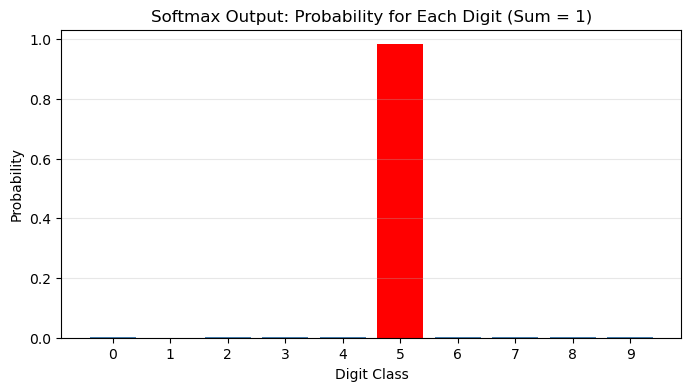

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(z):
    exp_z = np.exp(z - np.max(z))  # 수치 안정성을 위해 최댓값을 뺌
    return exp_z / exp_z.sum()

# MNIST: 숫자 5 이미지에 대한 모델 내부 점수 (가상)
scores = np.array([-2.1, -3.5, -1.2, -2.8, -1.5, 4.3, -2.0, -1.8, -2.3, -1.9])
probs = softmax(scores)

print('MNIST Digit Classification Result (Image of digit 5)')
print('-' * 45)
for digit, (s, p) in enumerate(zip(scores, probs)):
    bar = '█' * int(p * 40)
    marker = ' ← predicted' if digit == np.argmax(probs) else ''
    print(f'Digit {digit}: score={s:5.1f}  prob={p:.4f}  {bar}{marker}')

print(f'\nSum of all probabilities: {probs.sum():.6f} (always 1)')

plt.figure(figsize=(8, 4))
colors = ['red' if i == np.argmax(probs) else 'steelblue' for i in range(10)]
plt.bar(range(10), probs, color=colors)
plt.title('Softmax Output: Probability for Each Digit (Sum = 1)')
plt.xlabel('Digit Class')
plt.ylabel('Probability')
plt.xticks(range(10))
plt.grid(True, alpha=0.3, axis='y')
plt.show()

---
## 4. 최종 요약 정리 📝

| 핵심 알고리즘 | 오차/결과의 확률 가정 | 수학이 만들어낸 마법의 함수 | 우리가 써먹은 마법 |
|---------|---------|-------------|--------|
| **선형 회귀** | 수많은 잡원인이 합쳐진 **정규분포** 🔔 | **RMSE (루트 평균 제곱 오차)** | 캘리포니아 동네 집값 맞히기 (2장) |
| **로지스틱 회귀** | 동전 던지기! **베르누이 분포** 🪙 | **시그모이드 (Sigmoid)** | 스팸 메일 똑똑하게 걸러내기 (4장) |
| **소프트맥스 회귀** | 주사위 굴리기! **카테고리 분포** 🎲 | **소프트맥스 (Softmax)** | 꼬불꼬불 손글씨 글자 식별하기 (3장) |

우리가 이토록 골치 아프게 배웠던 이 세 가지 알고리즘은, 이 복잡한 수식 덩어리 안에 사실 모두 똑같은 아름다운 수학 철학과 생각의 뿌리를 공유하고 있다.

> **"주어진 데이터들이 근원적으로 어떤 모양(확률 분포)을 띠고 태어났는지 합리적으로 의심(가정)하라. 그리고 그 상황에서 이 데이터가 내 눈앞에 존재할 확률을 가장 최대(100%!)로 끌어올리는, 흠잡을 데 없는 완벽한 파라미터 셋을 기계에게 수단과 방법을 가리지 말고 찾게 지시하라!"**

이 무모하고 거창한 원칙을 통계학과 수학을 동원해 묵묵히 하나둘씩 증명해 내다 보니, 어느새 우리 양손에 **RMSE, 시그모이드, 소프트맥스**라는 최강의 무기가 쥐어져 있었을 뿐인 것이다. 알고리즘의 공식은 눈으로 보고 억지로 외우는 게 아니라, 이렇게 앞뒤 맥락의 감동으로 이어지는 것이다! 🎉